### packages

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# %matplotlib inline
from pathlib import Path
from time import sleep

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm as tqdm_bar
import time as _time
import random
import tempfile
from scipy.optimize import curve_fit

from orenge.general import *


# Experiment controls -------------------------------------------------------------

import qcodes as qc
from qcodes.dataset import (
    Measurement,
    initialise_or_create_database_at,
    load_or_create_experiment,
)
from qcodes.logger import start_all_logging
start_all_logging()
import qcodes.instrument_drivers.stanford_research as stanford_research

from spinapi import *

import pyvisa # for the SR830 lockin amplifier and Anritsu RF signal generator
pyvisa_rm = pyvisa.ResourceManager()

import os
import sys
ultolib_dir = os.path.dirname('C:/Users/nv-group02/Desktop/NV-Lab/ultolib')
sys.path.insert(0, ultolib_dir)
from ultolib import (anritsu, korad, spincore)
from ultolib.spincore import pulse

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\nv-group02\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\nv-group02\.qcodes\logs\260429-22836-qcodes.log


### utils

In [ ]:
class RigolDS1104:
    def __init__(self, resource):
        self.rm = pyvisa.ResourceManager()
        self.inst = self.rm.open_resource(resource)
        self.inst.timeout = 5000

    def idn(self):
        return self.inst.query("*IDN?")

    def get_waveform(self, channel=1):
        # Set source channel
        self.inst.write(f":WAV:SOUR CHAN{channel}")
        self.inst.write(":WAV:MODE NORM")
        self.inst.write(":WAV:FORM BYTE")

        # Query preamble (scaling info)
        preamble = self.inst.query(":WAV:PRE?").split(',')
        x_increment = float(preamble[4])
        x_origin = float(preamble[5])
        y_increment = float(preamble[7])
        y_origin = float(preamble[8])
        y_ref = float(preamble[9])

        # Get raw data
        raw = self.inst.query_binary_values(":WAV:DATA?", datatype='B', container=np.array)

        # Convert to voltage
        voltages = (raw - y_ref) * y_increment + y_origin
        times = np.arange(len(raw)) * x_increment + x_origin

        return times, voltages

    def close(self):
        self.inst.close()

class PBLogger:
    
    def __init__(self, pb):
        self._pb  = pb
        self._log = []   # list of dicts keyed by addr, channels, opcode, arg, duration

    # ------------------------------------------------------------------
    # Intercept send_instruction
    # ------------------------------------------------------------------
    def send(self, channels, opcode, arg, duration_ns):
        """Record instruction and forward to the real PulseBlaster."""
        addr = len(self._log)
        self._log.append({
            'addr':     addr,
            'channels': int(channels),
            'opcode':   opcode,
            'arg':      int(arg),
            'duration': int(duration_ns),
        })
        return self._pb.send_instruction(channels, opcode, arg, duration_ns)

    # ------------------------------------------------------------------
    # Instruction replay
    # ------------------------------------------------------------------
    def _replay(self, max_segs=50000):
        """
        Walk the instruction log following the SpinAPI branching rules.
        Returns a list of (t_start_ns, duration_ns, channels_int) tuples.
        Stops after the first BRANCH instruction (one full 2*Tref period).
        """
        segs      = []
        t         = 0
        pc        = 0
        loop_ctr  = {}   # pc_of_LOOP -> remaining passes (counts down)

        for _ in range(max_segs):
            if pc >= len(self._log):
                break
            ins = self._log[pc]
            segs.append((t, ins['duration'], ins['channels']))
            t += ins['duration']

            op = ins['opcode']
            if op == 'CONTINUE':
                pc += 1

            elif op == 'LOOP':
                # Initialize counter only on first visit.
                if pc not in loop_ctr:
                    loop_ctr[pc] = ins['arg']
                pc += 1   # always fall through to next instruction

            elif op == 'END_LOOP':
                la = ins['arg']          # address of the matching LOOP instruction
                loop_ctr[la] -= 1
                if loop_ctr[la] > 0:
                    pc = la              # jump back to the LOOP instruction itself
                else:
                    del loop_ctr[la]
                    pc += 1

            elif op == 'BRANCH':
                break                    # one full period captured; stop.

        return segs

    # ------------------------------------------------------------------
    # Live timing diagram
    # ------------------------------------------------------------------
    def plot_sequence(self, n_units=2):
        """
        Plot the first n_units of each half-cycle as replayed from the
        recorded instructions. A '...' gap separates HIGH and LOW sections.

        Parameters
        ----------
        n_units : int
            How many repetition units (each of duration Tunit ns) to show
            per half-cycle. Default 2 so the repeating pattern is visible.
        """
        segs = self._replay()

        # Find t_half: first time CH0 (bit 0) goes LOW after the HIGH half.
        t_half = None
        for t0, dur, ch in segs:
            if t0 > 0 and (ch & 1) == 0:
                t_half = t0
                break
        if t_half is None:
            raise RuntimeError("PBLogger.plot: could not find LOW half-cycle in replay.")

        t_show    = n_units * Tunit       # ns window to display per half
        segs_hi   = [(t0, d, ch) for t0, d, ch in segs if t0 <  t_half]
        segs_lo   = [(t0, d, ch) for t0, d, ch in segs if t0 >= t_half]

        ch_labels = ['CH0  Reference', 'CH1  Laser', 'CH2  MW Gate']
        colors    = ['tomato', 'seagreen', 'steelblue']
        gap_us    = 3.0   # visual gap symbol between HIGH and LOW panels

        def build_step(seg_list, t_origin, t_limit_ns, ch_idx):
            """
            Convert segments to step-plot arrays (xs_us, ys) for one channel.
            Uses steps-post convention: value at index i holds until index i+1.
            Only adds a new point when the level changes, so the arrays stay small.
            """
            pts     = []
            last_tb = 0.0
            for t0, dur, ch in seg_list:
                t_rel = float(t0) - float(t_origin)
                if t_rel >= t_limit_ns:
                    break
                if t_rel + dur <= 0:
                    continue
                ta  = max(t_rel, 0.0)
                tb  = min(t_rel + float(dur), float(t_limit_ns))
                lv  = (ch >> ch_idx) & 1
                last_tb = tb
                if not pts or pts[-1][1] != lv:
                    pts.append((ta / 1e3, lv))   # convert ns -> us
            if pts:
                pts.append((last_tb / 1e3, pts[-1][1]))
            return [p[0] for p in pts], [p[1] for p in pts]

        fig, axes = plt.subplots(3, 1, figsize=(12, 4.5), sharex=False)
        fig.subplots_adjust(hspace=0.08)
        t_win_us = t_show / 1e3

        for i, ax in enumerate(axes):
            xs_h, ys_h = build_step(segs_hi, 0,      t_show, i)
            xs_l, ys_l = build_step(segs_lo, t_half, t_show, i)
            xs_l_sh    = [x + t_win_us + gap_us for x in xs_l]

            ax.plot(xs_h, ys_h, lw=2.0, color=colors[i], drawstyle='steps-post')
            ax.plot(xs_l_sh, ys_l, lw=2.0, color=colors[i], drawstyle='steps-post', ls='--')
            ax.text(t_win_us + gap_us / 2, 0.5, '...',
                    ha='center', va='center', fontsize=13, color='gray')

            ax.axvspan(0,                          t_win_us,              alpha=0.07, color='orange')
            ax.axvspan(t_win_us + gap_us, t_win_us + gap_us + t_win_us,  alpha=0.07, color='dodgerblue')
            ax.set_ylim(-0.4, 1.6)
            ax.set_yticks([0, 1])
            ax.set_yticklabels(['0', '1'], fontsize=9)
            ax.set_ylabel(ch_labels[i], fontsize=9, rotation=0, ha='right', labelpad=90)
            ax.grid(True, alpha=0.15, axis='x')

            if i == 0:
                ax.text(t_win_us / 2, 1.3,
                        f'HIGH half  (ref=1, MW fires) -- {n_units}/{Nrepeat} units shown',
                        ha='center', fontsize=8, color='darkorange', style='italic')
                ax.text(t_win_us + gap_us + t_win_us / 2, 1.3,
                        f'LOW half  (ref=0, MW silent) -- {n_units}/{Nrepeat} units shown',
                        ha='center', fontsize=8, color='dodgerblue', style='italic')

        axes[-1].set_xlabel('Time (us)', fontsize=11)
        fig.suptitle(
            f'Instructed Pulse Sequence\n'
            f'(First {n_units} of {Nrepeat} units per half-cycle; solid = HIGH, dashed = LOW)',
            fontsize=9, y=1.02)
        plt.tight_layout()
        plt.show()
    
    def plot_capture(self, resource_string, pb):
        import time as _time

        ch_labels = ['CH0  Reference', 'CH1  Laser', 'CH2  MW Gate']
        colors    = ['gold', 'magenta', 'cyan']

        pb.start()
        _time.sleep(4.0 * Tref * 1e-9 * 1.2)

        xs_ms, ys_V = [], []
        for n in [1, 2, 3]:
            s = RigolDS1104(resource_string)
            t, v = s.get_waveform(channel=n)
            s.close()
            print(f'CH{n}: v min={v.min():.3f}  max={v.max():.3f}  mean={v.mean():.3f}')
            xs_ms.append(t * 1e3)
            ys_V.append(v)

        pb.stop()

        fig, axes = plt.subplots(3, 1, figsize=(12, 4.5), sharex=True)
        fig.subplots_adjust(hspace=0.08)

        for i, ax in enumerate(axes):
            ax.plot(xs_ms[i], ys_V[i], lw=1.2, color=colors[i])
            ax.set_ylabel(ch_labels[i], fontsize=9, rotation=0, ha='right', labelpad=90)
            ax.grid(True, alpha=0.15, axis='x')

        axes[-1].set_xlabel('Time (ms)', fontsize=11)
        fig.suptitle('Hardware Pulse Sequence (Oscilloscope capture)', fontsize=9)
        plt.tight_layout()
        plt.show()

class ODMRControlParams:
    """
    Computes optimal MW and lock-in control parameters for each frequency step.

    Physical references
    -------------------
    - Rabi frequency: Sewani et al. 2020, Sec. IV.C  (gamma_e = 28 GHz/T)
    - Antenna model:  Sewani et al. 2020, Fig. 2(e)   (Lorentzian, f0 = 2.49 GHz)
    - B1 calibration: Sewani et al. 2020, Fig. 2(d)   (306 uT at +24 dBm at resonance)
    - Lock-in ENBW:   ZI whitepaper, Table 1           (fNEP = 1/(4*tau_c) for n=1)
    - Settle time:    ZI whitepaper, Table 1           (99% settle = 4.61*tau_c for n=1)
    - Noise density:  SR830 spec, noted in notebook    (6 nV/sqrt(Hz))
    """

    GAMMA_E    = 28.0e9     # Hz/T   electron gyromagnetic ratio (Sewani 2020, Eq. 1)
    V_N        = 6.0e-9     # V/sqrt(Hz)  SR830 input noise density

    # Antenna parameters (Sewani et al. 2020, Fig. 2(e))
    F_ANT      = 2.49e9     # Hz  measured S11 minimum (resonance)
    BW_ANT     = 0.5e9      # Hz  estimated FWHM bandwidth from Fig. 2(e)
    P_REF_dBm  = 24.0       # dBm reference power level
    B1_PEAK    = 306.0e-6   # T   B1 field at resonance at P_REF

    def __init__(self, power_dBm, tau_c_s):
        """
        Parameters
        ----------
        power_dBm : float   MW output power in dBm (e.g. -6).
        tau_c_s   : float   Lock-in time constant in seconds (e.g. 30e-3).
        """
        self.power_dBm = power_dBm
        self.tau_c     = tau_c_s

    def antenna_gain(self, f_Hz):
        """
        Lorentzian power gain of antenna relative to its resonance peak (0..1).

        G(f) = (BW/2)^2 / ((f - f0)^2 + (BW/2)^2)

        Models the S11 Lorentzian shape from Sewani et al. 2020, Fig. 2(e).
        B1^2 (power) is proportional to G(f), so B1 scales as sqrt(G).
        """
        hw = self.BW_ANT / 2.0
        return hw**2 / ((f_Hz - self.F_ANT)**2 + hw**2)

    def B1(self, f_Hz):
        """
        Estimated oscillating B1 field at the diamond [T] for frequency f_Hz.

        B1(f, P) = B1_PEAK * 10^((P - P_ref)/20) * sqrt(G(f))

        The 10^((P-P_ref)/20) converts the dBm difference to a field (voltage)
        amplitude ratio. Source: Sewani et al. 2020, Sec. IV.C + Fig. 2(d).
        """
        field_ratio = 10.0 ** ((self.power_dBm - self.P_REF_dBm) / 20.0)
        return self.B1_PEAK * field_ratio * np.sqrt(self.antenna_gain(f_Hz))

    def rabi_freq(self, f_Hz):
        """
        Rabi frequency Omega_R [Hz] at f_Hz.

        Omega_R = (1/2) * gamma_e * B1(f)

        Source: Sewani et al. 2020, Sec. IV.C, text after Eq. (1).
        """
        return 0.5 * self.GAMMA_E * self.B1(f_Hz)

    def tau_pi(self, f_Hz):
        """
        Optimal pi-pulse duration [s] at f_Hz.

        tau_pi = 1 / (2 * Omega_R)

        This pulse length maximally inverts the spin population, maximizing
        ODMR contrast. Source: Sewani et al. 2020, Sec. V.B discussion of smw.
        """
        OR = self.rabi_freq(f_Hz)
        return 1.0 / (2.0 * OR) if OR > 0 else np.inf

    def enbw(self):
        """
        Equivalent noise-power bandwidth [Hz] for SR830 1st-order filter.

        fNEP = 1 / (4 * tau_c)

        Source: ZI whitepaper "Principles of lock-in detection", Table 1, n=1.
        """
        return 1.0 / (4.0 * self.tau_c)

    def settle_time_99pct(self):
        """
        Time [s] to settle to 99% of final value for 1st-order filter.

        lockin_settle_time(99%) = 4.61 * tau_c

        Source: ZI whitepaper, Table 1, n=1, "99%" column.
        """
        return 4.61 * self.tau_c

    def noise_rms(self):
        """
        RMS noise at SR830 output [V] within lock-in bandwidth.

        V_noise = V_n * sqrt(fNEP)

        where V_n = 6 nV/sqrt(Hz) is the SR830 input noise density.
        Source: ZI whitepaper, noise section; SR830 spec sheet.
        """
        return self.V_N * np.sqrt(self.enbw())

    def summary(self, f_Hz):
        b1   = self.B1(f_Hz)
        OR   = self.rabi_freq(f_Hz)
        tp   = self.tau_pi(f_Hz)
        enbw = self.enbw()
        t99  = self.settle_time_99pct()
        vn   = self.noise_rms()
        niceprint(
            f"**Optimal parameters for {f_Hz/1e9:.2f} GHz**  ──────────────────────────────────────────────── <br><br> "
            
            "$\\quad \\begin{array}{clll}"
            "\\textbf{Param} & \\textbf{Value} & \\textbf{Formula} & \\textbf{Source} \\\\"
            "\\hline"
            f" f                              & = {f_Hz/1e9:.4f}\\; {{\\rm GHz}} & &\\\\"
            f" B_1                            & = {b1*1e6:.3f}\\;   \\mu T       &                                  &{{\\rm Sewani\\; Fig.\\; 2(d)\\; model}} \\\\"
            f" \\Omega_R                      & = {OR/1e3:.2f}\\;   {{\\rm kHz}} & \\frac{{1}}{{2}} \\gamma_e B_1 &\\\\"
            f" \\tau_\\pi                     & = {tp*1e6:.2f}\\;   \\mu s       & \\frac{{1}}{{2\\Omega_R}}      &\\\\"
            f" ENBW                           & = {enbw:.2f}\\;     {{\\rm Hz}}  & \\frac{{1}}{{4\\tau_c}}        &{{\\rm ZI\\; Table\\; 1}} \\\\"
            f" t_{{\\rm settle}}              & = {t99*1e3:.1f}\\;  {{\\rm ms}}  & 4.61\\tau_c                    &{{\\rm ZI\\; Table\\; 1}} \\\\"
            f" {{\\rm RMS }} V_{{\\rm noise}} & = {vn*1e9:.2f}\\;   {{\\rm nV}}  & \\frac{{6 \\;nV}}{{\\sqrt{{\\rm Hz}}}} \\sqrt{{\\rm ENBW}} &\\\\"
            "\\end{array}$ <br><br>"
        )

def save_run_metadata(datasaver, sweep_params):
    import json

    snapshot = {
        'pulse_sequence' : {
            'Tref_ns'     : Tref,
            'Tlaser_ns'   : Tlaser,
            'Tmw_ns'      : Tmw,
            'Tpadding_ns' : Tpadding,
            'Twait_ns'    : Twait,
            'Tunit_ns'    : Tunit,
            'Nrepeat'     : Nrepeat,
            'f_ref_Hz'    : 1.0 / (2.0 * Tref * 1e-9),
        },
        'instruments' : {
            'lock_in_amp'   : lock_in_amp.snapshot(),
            'microwave_src' : microwave_src.snapshot(),
            'pulse_blaster' : pulse_blaster.snapshot(),
        },
        'sweep' : sweep_params,
    }

    datasaver.dataset.add_metadata(
        'experiment_snapshot',
        json.dumps(snapshot, indent=2),
    )
    return snapshot

def load_run_metadata(run_id):
    
    from qcodes.dataset import load_by_id

    ds   = load_by_id(run_id)
    raw  = ds.metadata.get('experiment_snapshot')

    if raw is None:
        print(f"Run {run_id} has no experiment_snapshot metadata.")
        print("Available metadata keys:", list(ds.metadata.keys()))
        return {}

    meta = json.loads(raw)
    print(json.dumps(meta, indent=2))
    return meta



### params

In [ ]:
# All times in nanoseconds — matches the template's spinapi unit convention
# (template: ms=1000000, us=1000, so Tref=2.5*ms=2500000, Tlaser=4*us=4000, etc.)

Tref     = 1000 * 16000   # ns  (2.5 ms half-period -> 200 Hz reference)
Tlaser   = 5_000       # ns  (4 µs)   template: Tlaser = 4*us
Tmw      = 10_000       # ns  (3 µs)   template: Tmw = 3*us
Tpadding = 1000         # ns  (0.25 µs) template: Tpadding = 0.25*us
# Nrepeat  = 1000        

# Tunit = Tref // Nrepeat                    # 10000 ns per laser+MW unit
# Twait = 1350 #Tunit - Tlaser - Tmw - Tpadding   # 2750 ns between laser and MW
# assert Twait > 0, "Treference is too short for requested Nrepeat"

#NOTE: try this:
Twait    = 1_350          # ns  (1.35 us pre-MW wait; laser off, MW not yet on)

# derive Tunit and Nrepeat from the timing budget
Tunit   = Tlaser + Twait + Tmw + Tpadding   # 17350 ns = 17.35 us
Nrepeat = Tref // Tunit  

lockin_settle_time = 0.2   # s

# Channel bitmasks — template uses 8-bit patterns with bits 4-7 mirroring 0-3
# for oscilloscope monitoring.  The QCodes driver uses 4 channels (bits 0-3).
# FLAG_MASK (bits 21-23) is ORed in automatically by send_instruction.
REF     = 0b00010001   # CH0 -> SR830 REF IN
LASER   = 0b00100010   # CH1 -> AOM / laser gate
MW      = 0b01000100   # CH2 -> Anritsu I-input (MW gate)
OFF     = 0b00000000

print(f"Tunit  = {Tunit} ns  ({Tunit/1e3:.1f} µs)")
print(f"Twait  = {Twait} ns  ({Twait/1e3:.2f} µs)")
print(f"T_HIGH = {Tref} ns  ({Tref/1e6:.1f} ms) [verified]")
print(f"T_LOW  = {Tref} ns  ({Tref/1e6:.1f} ms) [verified]")

Tunit  = 16000 ns  (16.0 µs)
Twait  = 1350 ns  (1.35 µs)
T_HIGH = 16000000 ns  (16.0 ms) [verified]
T_LOW  = 16000000 ns  (16.0 ms) [verified]


In [41]:
mwpower = -6
tau_c = 30e-3
ctrl = ODMRControlParams(power_dBm=mwpower, tau_c_s=tau_c)
ctrl.summary(2.87e9)

niceprint('---')
print(f"Current Tmw = {Tmw/1e3:.1f} us")
print(f"Optimal tau_pi at 2.87 GHz = {ctrl.tau_pi(2.87e9)*1e6:.2f} us")
print(f"(Difference = {(Tmw/1e3 - ctrl.tau_pi(2.87e9)*1e6):.2f} us)")

**Optimal parameters for 2.87 GHz**  ──────────────────────────────────────────────── <br><br> $\quad \begin{array}{clll}\textbf{Param} & \textbf{Value} & \textbf{Formula} & \textbf{Source} \\\hline f                              & = 2.8700\; {\rm GHz} & &\\ B_1                            & = 5.318\;   \mu T       &                                  &{\rm Sewani\; Fig.\; 2(d)\; model} \\ \Omega_R                      & = 74.46\;   {\rm kHz} & \frac{1}{2} \gamma_e B_1 &\\ \tau_\pi                     & = 6.72\;   \mu s       & \frac{1}{2\Omega_R}      &\\ ENBW                           & = 8.33\;     {\rm Hz}  & \frac{1}{4\tau_c}        &{\rm ZI\; Table\; 1} \\ t_{\rm settle}              & = 138.3\;  {\rm ms}  & 4.61\tau_c                    &{\rm ZI\; Table\; 1} \\ {\rm RMS } V_{\rm noise} & = 17.32\;   {\rm nV}  & \frac{6 \;nV}{\sqrt{\rm Hz}} \sqrt{\rm ENBW} &\\\end{array}$ <br><br>

---

Current Tmw = 10.0 us
Optimal tau_pi at 2.87 GHz = 6.72 us
(Difference = 3.28 us)


### setup

#### instruments

In [42]:
for name in ['lock_in_amp', 'microwave_src', 'pulse_blaster']:
    if name in qc.instrument.instrument.Instrument._all_instruments:
        qc.instrument.instrument.Instrument._all_instruments[name].close()

pyvisa_rm = pyvisa.ResourceManager()
for resource in pyvisa_rm.list_resources(): print(resource)

pulse_blaster = spincore.PulseBlasterESRPRO(name='pulse_blaster', board_number=0)
pulse_blaster.core_clock(500)

_resource = pyvisa_rm.open_resource('ASRL5::INSTR')
_resource.baud_rate = 9600
_resource.data_bits = 8
_resource.write('OUTX 0\r')

lock_in_amp = stanford_research.SR830(
    name='lock_in_amp',
    address=None,
    terminator='\r',
    resource=_resource,
)
# External reference from PulseBlaster CH0 wired to SR830 REF IN.
lock_in_amp.reference_source.set('external')
lock_in_amp.input_config('a')
lock_in_amp.time_constant(tau_c)
lock_in_amp.sensitivity(500e-5)
print(f"Time constant : {tau_c*1e3:.0f} ms")
print(f"Settle time   : {lockin_settle_time*1e3:.0f} ms  ({lockin_settle_time/tau_c:.1f} tau_c)")

mwpower = -6
microwave_src = anritsu.MG3681A(
    name='microwave_src',
    address='ASRL4::INSTR',
    terminator='\r\n',
)
microwave_src.output_level_unit('dBm')
microwave_src.IQ_modulation('EXT')
microwave_src.power(mwpower)
microwave_src.output('OFF')

scope = RigolDS1104('USB0::0x1AB1::0x04CE::DS1ZC232502790::INSTR')
pulse_blaster.stop()

USB0::0x1AB1::0x04CE::DS1ZC232502790::INSTR
ASRL1::INSTR
ASRL3::INSTR
ASRL4::INSTR
ASRL5::INSTR
ASRL6::INSTR
Connected to: Stanford_Research_Systems SR830 (serial:s/n32132, firmware:ver1.07) in 0.21s
Time constant : 30 ms
Settle time   : 200 ms  (6.7 tau_c)
Connected to: ANRITSU MG3681A (serial:6100146424, firmware:3.03) in 0.07s


0

#### qcodes

In [43]:
MW_freq = qc.ManualParameter('mw_frequency', unit='Hz')
LI_R    = qc.ManualParameter('signal',       unit='V')

initialise_or_create_database_at(Path.cwd() / 'ODMR_Lab.db')

experiment = load_or_create_experiment(
    experiment_name='ODMR_Spectrum',
    sample_name='NV_diamond',
)

meas = Measurement(exp=experiment, name='zero_field_ODMR')
meas.register_parameter(MW_freq)
meas.register_parameter(LI_R, setpoints=(MW_freq,))

### experiments

#### pulse sequence

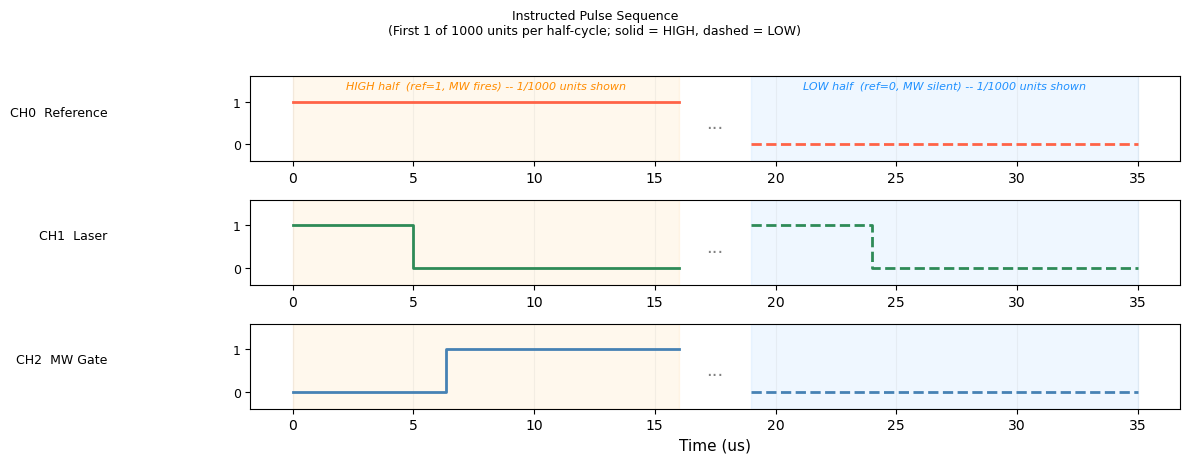

CH1: v min=81.200  max=85.800  mean=83.051
CH2: v min=-36.200  max=-28.040  mean=-32.811
CH3: v min=-32.800  max=-24.600  mean=-29.395


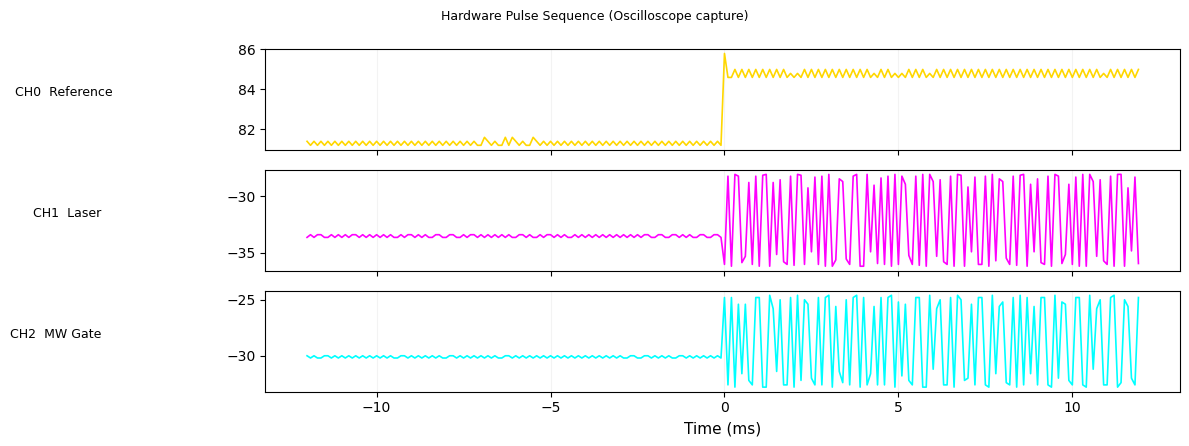

In [44]:
pulse_blaster.start_programming()
pb_log = PBLogger(pulse_blaster)   # wraps send_instruction; records every call

# ── HIGH HALF-CYCLE ───────────────────────────────────────────────────────────

# Step 1: Laser initializes spin into |0>_g via optical pumping.
start = pb_log.send(REF | LASER, 'CONTINUE', 0, Tlaser)

# Step 2: Pre-MW wait. Laser is OFF; MW not yet on.
#         Twait = Tunit - Tlaser - Tmw - Tpadding ensures unit timing sums correctly.
pb_log.send(REF, 'CONTINUE', 0, Twait)

# Step 3: MW ON. Drives |0>_g -> |+/-1>_g if frequency is resonant.
pb_log.send(REF | MW, 'CONTINUE', 0, Tmw)

# Step 4: LOOP instruction (= inter-unit Tpadding gap AND loop start).
#         Executes Nrepeat-1 times total (combined with Steps 5-7).
loop_high = pb_log.send(REF, 'LOOP', Nrepeat - 1, Tpadding)

# Steps 5-7: Loop body -- laser, wait, MW (same structure as Steps 1-3).
pb_log.send(REF | LASER, 'CONTINUE', 0, Tlaser)
pb_log.send(REF,         'CONTINUE', 0, Twait)
pb_log.send(REF | MW,    'END_LOOP', loop_high, Tmw)

# Step 8: Final Tpadding closes the last unit of the HIGH half.
pb_log.send(REF, 'CONTINUE', 0, Tpadding)

# ── LOW HALF-CYCLE ────────────────────────────────────────────────────────────

# Step 9: First laser pulse of LOW half (unrolled, outside loop).
pb_log.send(LASER, 'CONTINUE', 0, Tlaser)

# Step 10: LOOP -- fills the idle gap between laser pulses.
loop_low = pb_log.send(OFF, 'LOOP', Nrepeat - 1, Tunit - Tlaser)

# Step 11 (loop body): Laser ON again; MW stays silent.
pb_log.send(LASER, 'END_LOOP', loop_low, Tlaser)

# Step 12: Idle + BRANCH back to start for continuous looping.
pb_log.send(OFF, 'BRANCH', start, Tunit - Tlaser)

pulse_blaster.stop_programming()

# ───────────────────────────────────────────────────────────────────────────────
pb_log.plot_sequence(1)
pb_log.plot_capture('USB0::0x1AB1::0x04CE::DS1ZC232502790::INSTR', pulse_blaster)

#### negative test

=== Negative Test (MW OFF) ===
Mean R           : 869124.30 nV
Std R (noise)    : 191027.19 nV
Theoretical floor: 17.32 nV  (ZI whitepaper, Table 1)
SNR check: if a real ODMR peak appears here, check for MW leakage.


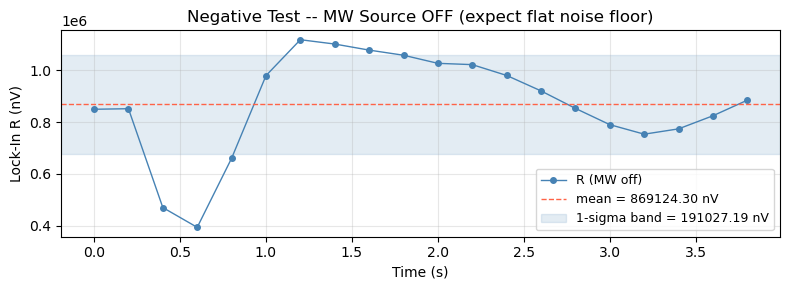

In [45]:
# ── Negative test: MW source OFF, PulseBlaster running ────────────────────────
# Expected: R is flat at the noise floor (~17 nV). No ODMR dip.
# This validates the lock-in reference lock and gives the empirical noise floor.

N_neg = 20
pulse_blaster.start()
sleep(0.1)
# microwave_src.output('ON') is intentionally NOT called here.

neg_readings = []
for i in range(N_neg):
    sleep(lockin_settle_time)
    neg_readings.append(lock_in_amp.R())

pulse_blaster.stop()

neg_arr  = np.array(neg_readings)
neg_mean = neg_arr.mean()
neg_std  = neg_arr.std()

print("=== Negative Test (MW OFF) ===")
print(f"Mean R           : {neg_mean*1e9:.2f} nV")
print(f"Std R (noise)    : {neg_std*1e9:.2f} nV")
print(f"Theoretical floor: {ctrl.noise_rms()*1e9:.2f} nV  (ZI whitepaper, Table 1)")
print(f"SNR check: if a real ODMR peak appears here, check for MW leakage.")

fig, ax = plt.subplots(figsize=(8, 3))
t_neg = np.arange(N_neg) * lockin_settle_time
ax.plot(t_neg, neg_arr * 1e9, 'o-', ms=4, lw=1, color='steelblue', label='R (MW off)')
ax.axhline(neg_mean * 1e9, color='tomato', ls='--', lw=1,
           label=f'mean = {neg_mean*1e9:.2f} nV')
ax.axhspan((neg_mean - neg_std) * 1e9, (neg_mean + neg_std) * 1e9,
           alpha=0.15, color='steelblue', label=f'1-sigma band = {neg_std*1e9:.2f} nV')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Lock-In R (nV)')
ax.set_title('Negative Test -- MW Source OFF (expect flat noise floor)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### coarse sweep

In [ ]:
# ── Phase 1: coarse sweep to locate the ODMR peak ─────────────────────────────
# Sewani et al. 2020, Fig. 4(b): zero-field peak at D = 2.87 GHz.
# Step = 6.25 MHz < FWHM (~14 MHz), so the peak will be resolved.

f1_start  = 2.77e9    # Hz  (template: freq_min = 2.77 GHz)
f1_stop   = 2.97e9    # Hz  (template: freq_max = 2.97 GHz)
n1_pts    = 32

freq_list_1        = np.linspace(f1_start, f1_stop, n1_pts)
idx1_rand          = np.random.permutation(n1_pts)
freq_list_1_rand   = freq_list_1[idx1_rand]   # randomized order for MW settling

step_1_GHz = (f1_stop - f1_start) / (n1_pts - 1) / 1e9
print(f"Phase 1: {f1_start/1e9:.2f} to {f1_stop/1e9:.2f} GHz")
print(f"Step   : {step_1_GHz:.2f} GHz  ({n1_pts} pts)")
print(f"Total  : ~{n1_pts * lockin_settle_time:.0f} s  (randomized order)")

# ── Phase 1 sweep ──────────────────────────────────────────────────────────────
meas1 = Measurement(exp=experiment, name='zero_field_ODMR_coarse')
meas1.register_parameter(MW_freq)
meas1.register_parameter(LI_R, setpoints=(MW_freq,))

pulse_blaster.start()
sleep(10 * tau_c) 
microwave_src.output('ON')

r1_dict = {}
with meas1.run() as datasaver1:
    save_run_metadata(datasaver1, sweep_params={
        'name'      : 'coarse sweep',
        'f_start_Hz' : f1_start,
        'f_stop_Hz'  : f1_stop,
        'n_pts'      : n1_pts,
        'step_Hz'    : (f1_stop - f1_start) / (n1_pts - 1),
        'randomized' : True,
    })
    for f_mw in tqdm_bar(freq_list_1_rand, desc='Phase 1 (coarse)', unit='pt'):
        microwave_src.frequency(f_mw)
        sleep(lockin_settle_time)
        r_val = lock_in_amp.R()
        r1_dict[f_mw] = r_val
        datasaver1.add_result((MW_freq, f_mw), (LI_R, r_val))

microwave_src.output('OFF')
pulse_blaster.stop()

# Sort results back to frequency order for fitting.
r1_arr = np.array([r1_dict[f] for f in freq_list_1])
print(f"Phase 1 done. Run ID: {datasaver1.dataset.run_id}")

Phase 1: 2.77 to 2.97 GHz
Step   : 0.01 GHz  (32 pts)
Total  : ~6 s  (randomized order)
Starting experimental run with id: 55. 


Phase 1 (coarse):   0%|          | 0/32 [00:00<?, ?pt/s]

Phase 1 done. Run ID: 55


Phase 1 fit:  f0 = 2.8684 GHz,  FWHM = 0.1 GHz


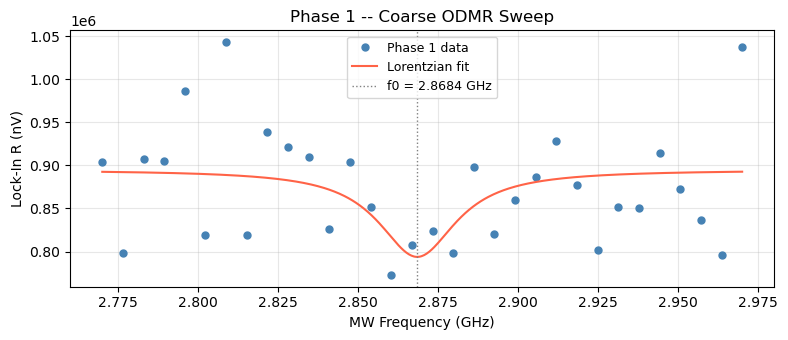

In [47]:
# ── Fit Phase 1 data to locate peak center ────────────────────────────────────
def lorentzian(f, f0, gamma, A, C):
    return C + A * (gamma / 2)**2 / ((f - f0)**2 + (gamma / 2)**2)

p0_1 = [2.87e9, 20e6, r1_arr.max() - r1_arr.min(), r1_arr.min()]
try:
    popt_1, _ = curve_fit(lorentzian, freq_list_1, r1_arr, p0=p0_1, maxfev=5000)
    f0_coarse    = popt_1[0]
    gamma_coarse = abs(popt_1[1])
    print(f"Phase 1 fit:  f0 = {f0_coarse/1e9:.4f} GHz,  FWHM = {2*gamma_coarse/1e9:.1f} GHz")
except RuntimeError:
    f0_coarse    = freq_list_1[np.argmax(r1_arr)]
    gamma_coarse = 20e6
    popt_1       = None
    print(f"Fit failed; using argmax: f0 = {f0_coarse/1e9:.4f} GHz")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(freq_list_1 / 1e9, r1_arr * 1e9, 'o', ms=5, color='steelblue', label='Phase 1 data')
if popt_1 is not None:
    f_fine_1 = np.linspace(freq_list_1.min(), freq_list_1.max(), 500)
    ax.plot(f_fine_1 / 1e9, lorentzian(f_fine_1, *popt_1) * 1e9,
            color='tomato', lw=1.5, label='Lorentzian fit')
ax.axvline(f0_coarse / 1e9, color='gray', ls=':', lw=1, label=f'f0 = {f0_coarse/1e9:.4f} GHz')
ax.set_xlabel('MW Frequency (GHz)')
ax.set_ylabel('Lock-In R (nV)')
ax.set_title('Phase 1 -- Coarse ODMR Sweep')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### fine sweep

In [ ]:
# ── Phase 2: fine sweep centered on the peak found in Phase 1 ─────────────────
window_Hz  = 3 * (2.0 * gamma_coarse)   # +/- 3*FWHM window
f2_start   = max(f0_coarse - window_Hz, f1_start)
f2_stop    = min(f0_coarse + window_Hz, f1_stop)
n2_pts     = 128

freq_list_2      = np.linspace(f2_start, f2_stop, n2_pts)
idx2_rand        = np.random.permutation(n2_pts)
freq_list_2_rand = freq_list_2[idx2_rand]

step_2_GHz = (f2_stop - f2_start) / (n2_pts - 1) / 1e9
print(f"Phase 2: {f2_start/1e9:.4f} to {f2_stop/1e9:.4f} GHz")
print(f"Step   : {step_2_GHz:.3f} GHz  ({n2_pts} pts)")
print(f"Total  : ~{n2_pts * lockin_settle_time:.0f} s  (randomized order)")

# Print optimal tau_pi for each Phase 2 frequency step.
print("\n=== Optimal tau_pi per Phase 2 frequency step ===")
print(f"{'f (GHz)':>10}  {'B1 (uT)':>8}  {'Omega_R (kHz)':>14}  {'tau_pi (us)':>12}")
sample_idx = np.linspace(0, n2_pts - 1, 8, dtype=int)
for i in sample_idx:
    f = freq_list_2[i]
    b1 = ctrl.B1(f)
    OR = ctrl.rabi_freq(f)
    tp = ctrl.tau_pi(f)
    print(f"{f/1e9:>10.4f}  {b1*1e6:>8.2f}  {OR/1e3:>14.2f}  {tp*1e6:>12.2f}")
print(f"\nCurrent Tmw = {Tmw/1e3:.1f} us (fixed for all steps in this sequence)")

# ── Phase 2 sweep ──────────────────────────────────────────────────────────────
meas2 = Measurement(exp=experiment, name='zero_field_ODMR_fine')
meas2.register_parameter(MW_freq)
meas2.register_parameter(LI_R, setpoints=(MW_freq,))

pulse_blaster.start()
sleep(10 * tau_c) 
microwave_src.output('ON')

r2_dict = {}
with meas2.run() as datasaver2:
    save_run_metadata(datasaver2, sweep_params={
        'name'      : 'fine sweep',
        'f_start_Hz' : f2_start,
        'f_stop_Hz'  : f2_stop,
        'n_pts'      : n2_pts,
        'step_Hz'    : step_2_GHz * 1e9,
        'randomized' : True,
    })
    for f_mw in tqdm_bar(freq_list_2_rand, desc='Phase 2 (fine)', unit='pt'):
        microwave_src.frequency(f_mw)
        sleep(lockin_settle_time)
        r_val = lock_in_amp.R()
        r2_dict[f_mw] = r_val
        datasaver2.add_result((MW_freq, f_mw), (LI_R, r_val))

microwave_src.output('OFF')
pulse_blaster.stop()

r2_arr = np.array([r2_dict[f] for f in freq_list_2])
print(f"Phase 2 done. Run ID: {datasaver2.dataset.run_id}")

Phase 2: 2.7700 to 2.9700 GHz
Step   : 0.002 GHz  (128 pts)
Total  : ~26 s  (randomized order)

=== Optimal tau_pi per Phase 2 frequency step ===
   f (GHz)   B1 (uT)   Omega_R (kHz)   tau_pi (us)
    2.7700      6.44           90.23          5.54
    2.7983      6.09           85.32          5.86
    2.8267      5.77           80.76          6.19
    2.8550      5.47           76.55          6.53
    2.8834      5.19           72.66          6.88
    2.9117      4.93           69.08          7.24
    2.9401      4.70           65.78          7.60
    2.9700      4.47           62.58          7.99

Current Tmw = 10.0 us (fixed for all steps in this sequence)
Starting experimental run with id: 56. 


Phase 2 (fine):   0%|          | 0/128 [00:00<?, ?pt/s]

Phase 2 done. Run ID: 56


=== Measurement Accuracy ===
Peak center f0    : 2.86703 +/- 0.007 GHz
FWHM              : 0.00 +/- 0.09 GHz
Amplitude A       : 6547.79 nV
Noise floor (meas): 25628.95 nV  (off-resonance std of data)
Noise floor (theo): 17.32 nV  (ZI whitepaper Table 1)
Peak SNR          : 0.3
Freq. step        : 0.002 GHz
Points per FWHM   : 2.1
Freq. precision   : 0.007 GHz  (1-sigma from covariance)
Contrast C        : 0.75 %  (= A / baseline)


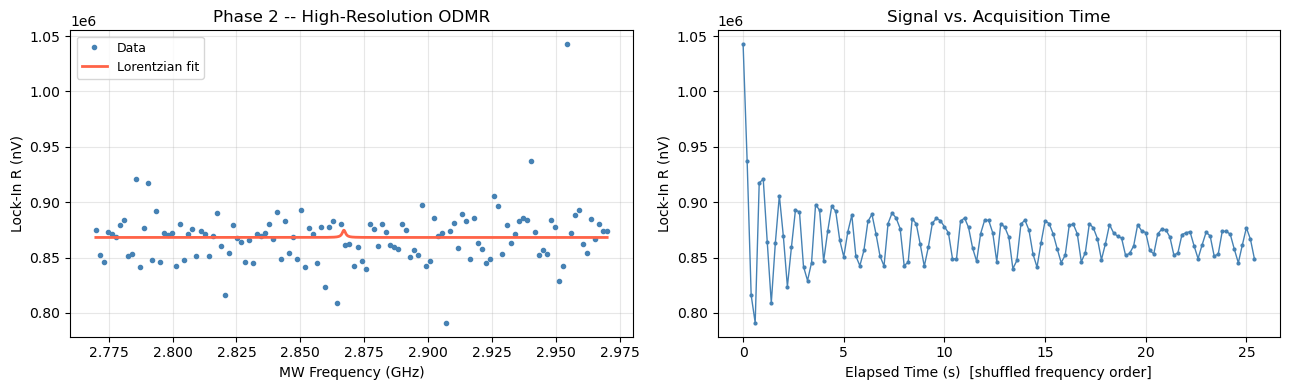

In [49]:
# ── Lorentzian fit to Phase 2 ─────────────────────────────────────────────────
f_arr_2 = freq_list_2
r_arr_2 = r2_arr
f_lo, f_hi = f_arr_2.min(), f_arr_2.max()
sig_range   = r_arr_2.max() - r_arr_2.min()
lower = [f_lo,  1e4,   0,             r_arr_2.min() - sig_range]
upper = [f_hi,  100e6, sig_range * 2, r_arr_2.max() + sig_range]

p0_2 = [f0_coarse, gamma_coarse, r_arr_2.max() - r_arr_2.min(), r_arr_2.min()]
p0_2 = [float(np.clip(p, lo, hi)) for p, lo, hi in zip(p0_2, lower, upper)]

popt_2, pcov_2 = curve_fit(
    lorentzian, f_arr_2, r_arr_2,
    p0     = p0_2,
    bounds = (lower, upper),
    maxfev = 5000,
)
f0_fit, gamma_fit, A_fit, C_fit = popt_2
perr_2 = np.sqrt(np.diag(pcov_2))

# Noise floor: std of points outside +/- 2*FWHM from the fitted peak.
off_mask = np.abs(f_arr_2 - f0_fit) > 2.0 * (2.0 * gamma_fit)
noise_empirical = r_arr_2[off_mask].std() if off_mask.sum() >= 3 else ctrl.noise_rms()

# Measurement accuracy summary.
print("=== Measurement Accuracy ===")
print(f"Peak center f0    : {f0_fit/1e9:.5f} +/- {perr_2[0]/1e9:.3f} GHz")
print(f"FWHM              : {2*gamma_fit/1e9:.2f} +/- {2*perr_2[1]/1e9:.2f} GHz")
print(f"Amplitude A       : {A_fit*1e9:.2f} nV")
print(f"Noise floor (meas): {noise_empirical*1e9:.2f} nV  (off-resonance std of data)")
print(f"Noise floor (theo): {ctrl.noise_rms()*1e9:.2f} nV  (ZI whitepaper Table 1)")
print(f"Peak SNR          : {A_fit/noise_empirical:.1f}")
print(f"Freq. step        : {step_2_GHz:.3f} GHz")
print(f"Points per FWHM   : {2*gamma_fit/(step_2_GHz*1e9):.1f}")
print(f"Freq. precision   : {perr_2[0]/1e9:.3f} GHz  (1-sigma from covariance)")
print(f"Contrast C        : {A_fit/abs(C_fit)*100:.2f} %  (= A / baseline)")

f_fine_2 = np.linspace(f_arr_2.min(), f_arr_2.max(), 2000)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: spectrum + Lorentzian fit.
axes[0].plot(f_arr_2 / 1e9, r_arr_2 * 1e9 , 'o', ms=3, color='steelblue', label='Data')
axes[0].plot(f_fine_2 / 1e9, lorentzian(f_fine_2, *popt_2) * 1e9,
             color='tomato', lw=2, label='Lorentzian fit')
axes[0].set_xlabel('MW Frequency (GHz)')
axes[0].set_ylabel('Lock-In R (nV)')
axes[0].set_title('Phase 2 -- High-Resolution ODMR')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: signal vs. acquisition time in shuffled frequency order.
# A flat or slowly varying trace here means no systematic drift.
r2_timeorder = np.array([r2_dict[freq_list_2_rand[i]] for i in range(n2_pts)])
t_acq = np.arange(n2_pts) * lockin_settle_time
axes[1].plot(t_acq, r2_timeorder * 1e9, lw=1, marker='o', ms=2, color='steelblue')
axes[1].set_xlabel('Elapsed Time (s)  [shuffled frequency order]')
axes[1].set_ylabel('Lock-In R (nV)')
axes[1].set_title('Signal vs. Acquisition Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### ultra fine sweep

In [ ]:
# ── Phase 3: ultra-fine sweep centered on Phase 2 fitted peak ─────────────────
window_3_Hz = 2.0 * gamma_fit          # +/- 1 FWHM around the fitted center
f3_start    = max(f0_fit - window_3_Hz, f1_start)
f3_stop     = min(f0_fit + window_3_Hz, f1_stop)
n3_pts      = 128

freq_list_3      = np.linspace(f3_start, f3_stop, n3_pts)
idx3_rand        = np.random.permutation(n3_pts)
freq_list_3_rand = freq_list_3[idx3_rand]

step_3_GHz = (f3_stop - f3_start) / (n3_pts - 1) / 1e9
print(f"Phase 3: {f3_start/1e9:.5f} to {f3_stop/1e9:.5f} GHz")
print(f"Step   : {step_3_GHz:.4f} GHz  ({n3_pts} pts)")
print(f"Total  : ~{n3_pts * lockin_settle_time:.0f} s  (randomized order)")

# ── Phase 3 sweep ──────────────────────────────────────────────────────────────
meas3 = Measurement(exp=experiment, name='zero_field_ODMR_ultrafine')
meas3.register_parameter(MW_freq)
meas3.register_parameter(LI_R, setpoints=(MW_freq,))

pulse_blaster.start()
sleep(10 * tau_c) 
microwave_src.output('ON')

r3_dict = {}
with meas3.run() as datasaver3:
    save_run_metadata(datasaver3, sweep_params={
        'name'      : 'ultra fine sweep',
        'f_start_Hz' : f3_start,
        'f_stop_Hz'  : f3_stop,
        'n_pts'      : n3_pts,
        'step_Hz'    : step_3_GHz * 1e9,
        'randomized' : True,
    })
    for f_mw in tqdm_bar(freq_list_3_rand, desc='Phase 3 (ultra-fine)', unit='pt'):
        microwave_src.frequency(f_mw)
        sleep(lockin_settle_time)
        r_val = lock_in_amp.R()
        r3_dict[f_mw] = r_val
        datasaver3.add_result((MW_freq, f_mw), (LI_R, r_val))

microwave_src.output('OFF')
pulse_blaster.stop()

r3_arr = np.array([r3_dict[f] for f in freq_list_3])
print(f"Phase 3 done. Run ID: {datasaver3.dataset.run_id}")

Phase 3: 2.86380 to 2.87026 GHz
Step   : 0.0001 GHz  (128 pts)
Total  : ~26 s  (randomized order)
Starting experimental run with id: 57. 


Phase 3 (ultra-fine):   0%|          | 0/128 [00:00<?, ?pt/s]

Phase 3 done. Run ID: 57


=== Phase 3 Measurement Accuracy ===
Peak center f0    : 2.867285 +/- 0.0002 GHz
FWHM              : 0.001 +/- 0.001 GHz
Amplitude A       : 14508.65 nV
Noise floor (meas): 24864.53 nV  (off-resonance std of data)
Noise floor (theo): 17.32 nV  (ZI whitepaper Table 1)
Peak SNR          : 0.6
Freq. step        : 0.0001 GHz
Points per FWHM   : 16.3
Freq. precision   : 0.0002 GHz  (1-sigma from covariance)
Contrast C        : 1.68 %  (= A / baseline)


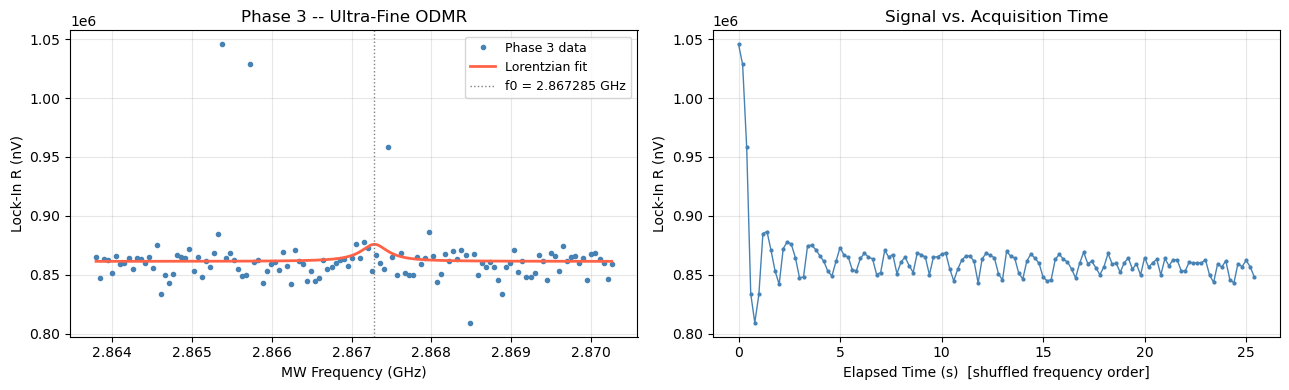

In [51]:
# ── Lorentzian fit to Phase 3 ─────────────────────────────────────────────────
f_arr_3   = freq_list_3
r_arr_3   = r3_arr
f_lo_3    = f_arr_3.min()
f_hi_3    = f_arr_3.max()
sig_range_3 = r_arr_3.max() - r_arr_3.min()

lower_3 = [f_lo_3, 1e4,   0,               r_arr_3.min() - sig_range_3]
upper_3 = [f_hi_3, 100e6, sig_range_3 * 2, r_arr_3.max() + sig_range_3]

p0_3 = [f0_fit, gamma_fit, sig_range_3, r_arr_3.max()]
p0_3 = [float(np.clip(p, lo, hi)) for p, lo, hi in zip(p0_3, lower_3, upper_3)]

popt_3, pcov_3 = curve_fit(
    lorentzian, f_arr_3, r_arr_3,
    p0     = p0_3,
    bounds = (lower_3, upper_3),
    maxfev = 50000,
)
f0_fit3, gamma_fit3, A_fit3, C_fit3 = popt_3
perr_3 = np.sqrt(np.diag(pcov_3))

off_mask_3      = np.abs(f_arr_3 - f0_fit3) > 2.0 * (2.0 * gamma_fit3)
noise_empirical3 = r_arr_3[off_mask_3].std() if off_mask_3.sum() >= 3 else ctrl.noise_rms()

print("=== Phase 3 Measurement Accuracy ===")
print(f"Peak center f0    : {f0_fit3/1e9:.6f} +/- {perr_3[0]/1e9:.4f} GHz")
print(f"FWHM              : {2*gamma_fit3/1e9:.3f} +/- {2*perr_3[1]/1e9:.3f} GHz")
print(f"Amplitude A       : {A_fit3*1e9:.2f} nV")
print(f"Noise floor (meas): {noise_empirical3*1e9:.2f} nV  (off-resonance std of data)")
print(f"Noise floor (theo): {ctrl.noise_rms()*1e9:.2f} nV  (ZI whitepaper Table 1)")
print(f"Peak SNR          : {A_fit3/noise_empirical3:.1f}")
print(f"Freq. step        : {step_3_GHz:.4f} GHz")
print(f"Points per FWHM   : {2*gamma_fit3/(step_3_GHz*1e9):.1f}")
print(f"Freq. precision   : {perr_3[0]/1e9:.4f} GHz  (1-sigma from covariance)")
print(f"Contrast C        : {A_fit3/abs(C_fit3)*100:.2f} %  (= A / baseline)")

f_fine_3 = np.linspace(f_arr_3.min(), f_arr_3.max(), 2000)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(f_arr_3 / 1e9, r_arr_3 * 1e9, 'o', ms=3, color='steelblue', label='Phase 3 data')
axes[0].plot(f_fine_3 / 1e9, lorentzian(f_fine_3, *popt_3) * 1e9,
             color='tomato', lw=2, label='Lorentzian fit')
axes[0].axvline(f0_fit3 / 1e9, color='gray', ls=':', lw=1,
                label=f'f0 = {f0_fit3/1e9:.6f} GHz')
axes[0].set_xlabel('MW Frequency (GHz)')
axes[0].set_ylabel('Lock-In R (nV)')
axes[0].set_title('Phase 3 -- Ultra-Fine ODMR')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

r3_timeorder = np.array([r3_dict[freq_list_3_rand[i]] for i in range(n3_pts)])
t_acq3 = np.arange(n3_pts) * lockin_settle_time
axes[1].plot(t_acq3, r3_timeorder * 1e9, lw=1, marker='o', ms=2, color='steelblue')
axes[1].set_xlabel('Elapsed Time (s)  [shuffled frequency order]')
axes[1].set_ylabel('Lock-In R (nV)')
axes[1].set_title('Signal vs. Acquisition Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### load previous

In [ ]:
from qcodes.dataset import initialise_or_create_database_at, load_by_id
from pathlib import Path
import json

initialise_or_create_database_at(Path('C:/Users/nv-group02/Desktop/NV-Lab/NV Lab raw Templates 2026/Experiments/ODMR_Lab.db'))
ds   = load_by_id(18)
meta = json.loads(ds.metadata['experiment_snapshot'])

print(meta['pulse_sequence']['Tmw_ns'])
print(meta['instruments']['lock_in_amp']['parameters']['time_constant']['value'])
# print(meta['sweep']['phase'])

### end